## 1. Preprocess Netherlands data


In [1]:
import pandas as pd
import seaborn as sns

df_nether_man = pd.read_csv('Leiden_20240401_netherlands.csv', sep=';', header=0)
df_nether_man = df_nether_man[df_nether_man['Site sequence number']!='SiteSeq'].copy()

l_num = ['PATNR', 'Age', 'BSE', 'Hb', 'MCV', 'Trom', 'Leuko'] # no 'Ht', 
l_essential = ['PATNR', 'Age', 'Sex', 'aCCP', 'RF', 'BSE', 'Hb', 'MCV', 'Trom', 'Leuko', 'SJC', 'TJC', 'FirstConsult'] # no 'Ht',  

df_nether_man = df_nether_man.rename(columns= {'Subject Id' : 'PATNR'})
#df = df.rename(columns= d_map)
print('No of patients:', len(df_nether_man))
#df_nether_man.head()

No of patients: 27


### 1.1 Format mannequin data (to align w/ Leiden)

#### Mannequin info description
Mannequin is simimlarly encoded as in the netherlands, namely: 

"1" = left, tender, "2" = left, swollen, "3" = right, tender, "4" = right swollen

In [2]:
l_joints = [col for col in df_nether_man][155:427]
l_swollenL_adjusted = ["Z_" + str(col) + '_L' for col in l_joints if ((' 2 - Code' in col) )]
l_swollenR_adjusted = ["Z_" + str(col) + '_R' for col in l_joints if ((' 4 - Code' in col) )]
l_tenderL_adjusted = ["P_" + str(col) + '_L' for col in l_joints if ((' 1 - Code' in col) )]
l_tenderR_adjusted = ["P_" + str(col) + '_R' for col in l_joints if ((' 3 - Code' in col) )]

l_swollenL = [col for col in l_joints if ((' 2 - Code' in col) )]
l_swollenR = [col for col in l_joints if ((' 4 - Code' in col) )]
l_tenderL = [col for col in l_joints if ((' 1 - Code' in col) )]
l_tenderR = [col for col in l_joints if ((' 3 - Code' in col) )]

d_rename_joints = dict(zip(l_swollenL, l_swollenL_adjusted))
d_rename_joints.update(dict(zip(l_swollenR, l_swollenR_adjusted)))
d_rename_joints.update(dict(zip(l_tenderL, l_tenderL_adjusted)))
d_rename_joints.update(dict(zip(l_tenderR, l_tenderR_adjusted)))

df_nether_man = df_nether_man.rename(columns = d_rename_joints)

In [3]:
list(df_nether_man.columns).index('Any joints tender or swollen') # Check!

156

In [4]:
import re 

def convert_Dutch_name_Mannequin(col_name):
    """
    Standardize the data by converting the name of a Nordstar (Danish) variable to the HIX equivalent
    
    Input:
        col_name = initial column name
    Return: 
        new_col = updated column name
        
    Translation:
        Kaak = cheek (temporomandibulair)
        SC = chest (sternoclavicular)
        AC = acromioclaviaculair
        Schouder = Shoulder
        Elleboog = Elbow
        Pols = Wrist
        Heup = Hip
        Knie = Knees
        Enkel = ankle
        Fotrot = tarsus
        IP-ledd stortå = IP feet
    """
    new_col = ""
    d_swollen = {'Z_' : 'Zwelling_', 'P_': 'Pijn_'}
    d_side = {'L': 'links', 'R' : 'rechts'} # 
    d_side_alt = {'L': 'L', 'R' : 'R'}
    
    d_entity = {'AC': 'acromioclaviaculair', 'Enkel': 'bovenste spronggewricht', 'STAL': 'onderste spronggewricht', 'Elleboog' : 'Elleboog', 'IP' : 'IP', 'FIP' : 'FIP', 'Knie' : 'knie', 'MCP' : 'mcp', 'TARS' : 'tarsometatarsaal', 'MTP' : 'mtp', 'PIP' : 'pip', 'SC' : 'sternoclaviculair', 'Schouder' : 'schouder', 'Kaak' : 'temporomandibulair', 'Pols' : 'pols','PIP' : 'pip', 'FPIP' : 'pip', 'DIP' : 'dip', 
                'Heup' : 'heup', 'NECK' : 'cervical spine'} 
    #print(col_name)
    #print(col_name[0:2], col_name[-1])
    if col_name[0:2] in d_swollen and col_name[-1] in d_side:
        col_name = col_name.replace('_IP 1', '_IP').replace('1 - Code_', '').replace('2 - Code_', '').replace('3 - Code_', '').replace('4 - Code_', '')
        
        # extract number if there is a number in joint
        if len([i for i in col_name[2:-2] if i.isdigit()]) > 0:
            joint = re.search("^(" + "|".join(d_entity.keys())+ ")$", ''.join([i for i in col_name[2:-4] if not i.isdigit()]))
        else :
            joint = re.search("^(" + "|".join(d_entity.keys())+ ")$", ''.join([i for i in col_name[2:-2] if not i.isdigit()]))
        #print('Joint:', joint, 'Extract', ''.join([i for i in col_name[2:-3] if not i.isdigit()]))
        if joint and '28' not in col_name:
            new_col += d_swollen[col_name[0:2]]
            
            # Account for exceptions
            if joint[0] == 'Elleboog' and col_name[-1]=='R' :
                entity = d_entity[joint[0]].lower()
            elif  joint[0] == 'Enkel' and col_name[-1]=='L':
                entity = 'bovenste spronggewicht' 
            elif joint[0] == 'IP' :
                if col_name[-3].isdigit():
                    entity = 'pip'
                else :
                    entity= 'IP'
            elif joint[0] == 'FIP':
                    entity = 'IP'
            else : 
                entity = d_entity[joint[0]]
            
            new_col += entity
            
            #print('-2', col_name[-3])
            if col_name[-3].isdigit() : # note specific joint
                new_col += " " + col_name[-3]
            if joint[0] in ['Elleboog', 'Schouder', 'Pols', 'SC', 'AC', 'TARS', 'Kaak']:
                new_col += " " + d_side_alt[col_name[-1]]  
            elif joint[0] in ['PIP'] :
                new_col += " " + d_side[col_name[-1]] + " hand"
            elif joint[0] in ['FIP']:
                new_col += " voet " + d_side[col_name[-1]]
            elif joint[0] in ['IP'] and entity=='pip' :
                new_col += " " + d_side[col_name[-1]] + " voet"
            
                
            else :
                new_col += " " + d_side[col_name[-1]]
        return new_col, True
    else : 
        return col_name, False
                 
# is vip pip
# ToDo ; Add Cervicular = NECK cervical spine_
# Missing: 'FPIP', 'STAL', 'NECK'
l_das_joints = ['AC', 'Enkel', 'Elleboog', 'IP', 'Knie', 'MCP', 'TARS', 'MTP', 'PIP',  'SC', 'Schouder',  'Kaak', 'Pols', 'FIP', 'DIP', 'Heup']              
d_joint = {}

for joint in l_das_joints:
    print('Joint:', joint)
    for col in df_nether_man.columns :
        #print(col)
        new_col = col.replace('Tarsus (voetwortel)', 'TARS').replace('IP grote teen', 'FIP')#.replace('_', '')
        #print(new_col)
        if joint in new_col and convert_Dutch_name_Mannequin(new_col)[1]:
            print('Old:', col, '\tNew:', convert_Dutch_name_Mannequin(new_col)[0])
            d_joint[col] = convert_Dutch_name_Mannequin(new_col)[0]

            
# Translate 
l_joints = list(d_joint.values())
df_nether_man= df_nether_man.rename(columns = d_joint)

# Keep only screening visits
#df_danmark_man = df_danmark_man[df_danmark_man['nordstar_nordstarvisitnumber']=='nordstar_visit_screening'].reset_index(drop=True)
#df_nether_man

Joint: AC
Old: P_AC 1 - Code_L 	New: Pijn_acromioclaviaculair L
Old: Z_AC 2 - Code_L 	New: Zwelling_acromioclaviaculair L
Old: P_AC 3 - Code_R 	New: Pijn_acromioclaviaculair R
Old: Z_AC 4 - Code_R 	New: Zwelling_acromioclaviaculair R
Joint: Enkel
Old: P_Enkel 1 - Code_L 	New: Pijn_bovenste spronggewicht links
Old: Z_Enkel 2 - Code_L 	New: Zwelling_bovenste spronggewicht links
Old: P_Enkel 3 - Code_R 	New: Pijn_bovenste spronggewricht rechts
Old: Z_Enkel 4 - Code_R 	New: Zwelling_bovenste spronggewricht rechts
Joint: Elleboog
Old: P_Elleboog 1 - Code_L 	New: Pijn_Elleboog L
Old: Z_Elleboog 2 - Code_L 	New: Zwelling_Elleboog L
Old: P_Elleboog 3 - Code_R 	New: Pijn_elleboog R
Old: Z_Elleboog 4 - Code_R 	New: Zwelling_elleboog R
Joint: IP
Old: P_IP 1 1 - Code_L 	New: Pijn_IP links
Old: Z_IP 1 2 - Code_L 	New: Zwelling_IP links
Old: P_IP 1 3 - Code_R 	New: Pijn_IP rechts
Old: Z_IP 1 4 - Code_R 	New: Zwelling_IP rechts
Old: P_PIP 2 1 - Code_L 	New: Pijn_pip 2 links hand
Old: Z_PIP 2 2 - Code

### 1.2 Cast categorical data to one hot encoding

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler # Z-score
from sklearn.preprocessing import RobustScaler  # Robust Z-score
from sklearn.preprocessing import PowerTransformer # Yeo-Johnson
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd

l_categorical = ['PATNR'] # , 'RF', 'aCCP', 'Sex', 'Age_Early', 'Age_Late'
l_joints = [ i for i in list(d_joint.values()) if i != '']

l_categorical.extend(l_joints)

new_df = df_nether_man[l_categorical].copy()
new_df = new_df.fillna(0).astype(int)#

# Perform OHE
def cast_to_one_hot(values):
    label_encoder = LabelEncoder()
    integer_encoded = label_encoder.fit_transform(values)

    onehot_encoder = OneHotEncoder(sparse=False)
    integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
    onehot_encoded = onehot_encoder.fit_transform(integer_encoded)
    df = pd.DataFrame(onehot_encoded, columns=[0, 1])
    df.index = np.arange(0, len(df))
    return df[0], df[1]

for cat in l_joints:
    # Easy fix: Cap at 1 
    if len(new_df[cat].unique())> 2:
        print('Headsup: there are more than 2 possibilities for column "%s" which is supposed to be binary, namely: %s' % (cat, str(new_df[cat].unique())))
    
    new_df[cat] = new_df[cat].apply(lambda x: 1 if x in [1,2,3, 4] else 0) # This implies that if it is missing it will also be recorded as 0
    #print(new_df[cat].unique())
    # If the column is non-informative
    if len(new_df[cat].unique()) == 1:
        if new_df[cat].iloc[0] == 0.0:
            new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = 1.0, 0.0
        else : 
            new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = 0.0, 1.0
        new_df = new_df.drop(columns=cat)
    else :
        new_df['%s_negative' % (cat)], new_df['%s_positive' % (cat)] = cast_to_one_hot(new_df[cat].values)
        new_df = new_df.drop(columns=cat)
new_df['PATNR']=new_df['PATNR'].astype(int)

### 1.3.1 Check missing

In [7]:
df_categoric = pd.read_csv('../../../new_data/5_clustering/df_categoric_wAge.csv', sep=',')
l_cat_shared = list(df_categoric[[col for col in df_categoric.columns if col in new_df.columns]].columns)
l_cat_shared.append('pseudoId')
l_cat_patnr =  l_cat_shared[:-1]
l_cat_patnr.append('PATNR')

pd.DataFrame({'Columns': l_cat_shared}).to_csv('Netherlands/Netherlands_columns_cat.csv', sep='|', index=False)

# Show missing variables
l_exclude = list(set(df_categoric.columns) - set(new_df.columns))
print('Missing variables:', l_exclude)

Missing variables: ['Zwelling_cmc 1 rechts_negative', 'RF', 'Pijn_cervical spine_positive', 'Zwelling_cmc 1 links_negative', 'Pijn_onderste spronggewricht rechts_positive', 'Pijn_dip 4 rechts voet_negative', 'Zwelling_dip 4 links voet_negative', 'Pijn_Manubrio sternaal gewricht_negative', 'aCCP', 'Pijn_dip 2 rechts voet_negative', 'Zwelling_dip 2 rechts voet_negative', 'Pijn_cmc 1 rechts_negative', 'Pijn_dip 5 rechts voet_negative', 'Zwelling_dip 4 links voet_positive', 'Zwelling_cmc 1 links_positive', 'Zwelling_dip 5 rechts voet_negative', 'Zwelling_cervical spine_positive', 'Zwelling_onderste spronggewricht links_negative', 'Pijn_dip 4 links voet_positive', 'Pijn_cmc 1 links_negative', 'Pijn_cmc 1 rechts_positive', 'Zwelling_dip 3 links voet_positive', 'Pijn_dip 2 links voet_negative', 'Pijn_dip 2 rechts voet_positive', 'Zwelling_cmc 1 rechts_positive', 'Pijn_sacro-ileacaal gewricht links_positive', 'Pijn_sacro-ileacaal gewricht rechts_positive', 'Zwelling_dip 5 rechts voet_positive'

## 1.4 Get numeric features

In [ ]:
df_nether_num = pd.read_csv('Leiden_20240401.csv', sep=';')
df_nether_num = df_nether_num[df_nether_num['CountryId']=='NETHERLANDS'].reset_index(drop=True)
# 'Hb', 'MCV', 'Trom', 'Leuko',
l_essential = ['PATNR', 'Age', 'Sex', 'aCCP', 'RF', 'BSE', 'CRP', 'SJC', 'TJC'] # no 'Ht',  

# Convert the float to datetime
df_nether_num['EventDate'] = df_nether_num['EventDate'].astype(str).str.split('.').str[0]
df_nether_num['EventDate'] = pd.to_datetime(df_nether_num['EventDate'], format='%Y%m%d')

df_nether_num = df_nether_num.rename(columns= {'SubjectId' : 'PATNR', 'CALC_AGE' : 'Age', 'PATSEXCD' : 'Sex', 'CALC_BMI' : 'BMI', 'ANSRVAL' : 'BSE',
 'ANCRPVAL' : 'CRP', 'ANCCPRESCD' : 'aCCP', 'ANRFRESCD' : 'RF'})

# Drop duplicates, keep only baseline information
df_nether_num = df_nether_num[df_nether_num['EventId']=='00_SCR']
#df_nether_num = df_nether_num.sort_values(by='EventDate').drop_duplicates(subset=['PATNR'], keep='first')
df_nether_num[l_essential]

#### show missingness per column

### Create categoric dataframe

In [9]:
df_categoric = df_nether_num[['PATNR', 'Sex', 'RF', 'aCCP']].merge(new_df, on='PATNR', how='left')
df_categoric['Sex'] = df_categoric['Sex'] - 1
l_cat = df_categoric.columns#[1:] # skip patient id

df_categoric.to_csv('Netherlands/df_netherlands_categoric_ohe.csv', sep='|', index=False)

## Export numeric

In [10]:
def normalizeLab(df):
    """
    Input: 
        df = complete dataframe
    
    Description:
        This function processes the Lab data. 
        Categorical data is subjected to a one-hot-encoding
        while the numerical data is cast to a z-scale as normalization
        
        Furthermore, the ESR (or BSE in dutch) is subjected to a 
        log-transformation.
    
    Output:
        df_dummies = dataframe with preprocessed categorical data 
        df_b = dataframe with preprocessed numerical data
    """
    l_num = ['BSE', 'Age'] # 'Ht', 
    
    # Log transform the ESR data
    df['BSE'] = np.log(df['BSE'])
    
    ct = ColumnTransformer([("num", PowerTransformer(), l_num)], remainder="passthrough")
    df_num= pd.DataFrame(ct.fit_transform(df[l_num]), columns=l_num)
    return df_num.merge(df['PATNR'], left_index=True, right_index=True)

l_num = ['PATNR',  'BSE', 'Age'] # 'Ht', 

# Define df lab
df_lab= df_nether_num[l_num].reset_index(drop=True).copy()

# Save lab data (unnormalized)
df_lab.to_csv(r'Netherlands/Netherlands_Lab_wide_unscaled.csv', sep='|', index=False)
print('Written to ../Netherlands/Netherlands_Lab_wide_unscaled.csv')

# Normalize lab values
df_lab_sc = normalizeLab(df_lab.copy())

# Save lab data (normalized)
df_lab_sc.to_csv(r'Netherlands/Netherlands_Lab_wide_scaled.csv', sep='|', index=False)
df_lab_sc.head()

print(len(df_lab_sc), len(df_lab_sc['PATNR'].unique()))

Written to ../Netherlands/Netherlands_Lab_wide_unscaled.csv
27 27


### Create baseline table

In [11]:
import numpy as np

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]

df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'ESR (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'ESR_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

df_subset = df_nether_num[~df_nether_num['Sex'].isna()].copy()
df_subset['Sex'] = df_subset['Sex'] -1
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['BSE'].isna()]['BSE']), IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[0], IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration']), IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[0], IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['BSE'].isna()]), (len(df_baseline[df_baseline['BSE'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100)
     
    ]
df_summary.loc[0] = generate_baseline_ref(df_subset, 'All')

df_summary = df_summary.reset_index(drop=True)
df_summary.T

,0
cluster,All
N,27
"Sex, F [n(%)]",17 (63.0)
Age (median+-IQR),49.0 (46.0-60.5)
RF [n(%)],25.0 (92.6)
ACPA [n(%)],23.0 (85.2)
ESR (median+-IQR),28.0 (12.0-38.0)
DAS28 (median+-IQR),4.5 (3.8-5.2)
SJC (median+-IQR),9.0 (5.5-10.0)
TJC (median+-IQR),12.0 (8.0-14.0)


## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [12]:
import pandas as pd

l_num = ['BSE', 'Age'] # 'Ht', 
#l_num = ['Leuko', 'Ht', 'Hb', 'MCV', 'Trom', 'BSE', 'Age', 'PATNR']

# Variables from development set
df_numeric = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_lab_scaled_demographics.csv', sep=',')
df_numeric['PATNR'] = df_numeric['pseudoId']
df_numeric = df_numeric[l_num].copy()
df_categoric= pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_categoric_wAge.csv', sep=',')
df_categoric['PATNR'] = df_categoric['pseudoId']
df_categoric = df_categoric[l_cat].copy()
l_num.append('PATNR')

# Variables from replication set
df_categoric_replication = pd.read_csv('Netherlands/df_netherlands_categoric_ohe.csv', sep='|')[l_cat]
df_numeric_replication = pd.read_csv('Netherlands/Netherlands_Lab_wide_scaled.csv', sep='|')[l_num]


# Select complete patients
l_essential = ['RF', 'aCCP', 'PATNR'] #  'Ht',
l_pat_repl = list(df_categoric_replication[l_essential].dropna()['PATNR'].unique())

df_categoric_replication = df_categoric_replication[df_categoric_replication['PATNR'].isin(l_pat_repl)].reset_index(drop=True)
df_numeric_replication = df_numeric_replication[df_numeric_replication['PATNR'].isin(l_pat_repl)].reset_index(drop=True)

df_categoric_replication = df_categoric_replication.fillna(0)
df_numeric_replication = df_numeric_replication.fillna(0)

### Create metadata

In [13]:
df_numeric_raw = pd.read_csv('Netherlands/Netherlands_Lab_wide_unscaled.csv', sep='|')[l_num]

df_meta_new = pd.merge(df_categoric_replication, df_numeric_raw, left_on='PATNR', right_on='PATNR')
df_meta_new['pseudoId'] = df_meta_new['PATNR'] 

### create combined metadata

In [14]:
# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0
metadata_RA['PATNR'] = metadata_RA['pseudoId'].str[:-2] 

df_meta_new['Replication'] = 1
df_meta_new['pseudoId'] = df_meta_new['PATNR'].copy()

df_meta_full = pd.concat([df_meta_new, metadata_RA])
df_meta_full.reset_index(drop=True)
df_meta_full.to_csv('Netherlands/Metadata_complete_Netherlands.csv', sep='|', index=False)

### #2.2 learn shared product space

In [15]:
import os, platform, subprocess, re

def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

get_processor_name()

' Intel(R) Xeon(R) CPU E5-2690 v3 @ 2.60GHz'

In [16]:
import time
import numpy as np
from mmae.multimodal_autoencoder import MultimodalAutoencoder # MMAE
import tensorflow as tf


# Be aware: Remove features with zero variation!!

input_shapes = {'Categoric': df_categoric[l_cat[1:]].shape[1:], 'Numeric': df_numeric.shape[1:]} 
data = [np.array(df_categoric[l_cat[1:]].values), np.array(df_numeric.values)]

# Number of units of each layer of encoder network
hidden_dims = [128, 64, 8] # 16?
# Output activation functions for each modality
output_activations = ['sigmoid' , 'relu'] # , 'relu'
# Name of Keras optimizer
optimizer = 'adam'
# Loss functions corresponding to a noise model for each modality
loss = ['bernoulli_divergence', 'gaussian_divergence']

# Set seed
#tf.keras.utils.set_random_seed(1234)
tf.random.set_seed(1234567)

# Construct autoencoder network
autoencoder = MultimodalAutoencoder(input_shapes, hidden_dims,
                                    output_activations)
autoencoder.compile(optimizer, loss)


t0 = time.time()
# Train model where input and output are the same
history = autoencoder.fit(data, epochs=100) # validation_data=validation_data # or 5000

t1 = time.time()
print('Time to create product space: ' + str(t1-t0))


# Get Latent space of original data
z_filtered = autoencoder.encode(data)
 
#tf.keras.models.save_model()
# Save maui model state (that only uses variables also present in replication set)
#maui_model.save('/exports/reum/tdmaarseveen/RA_Clustering/models/replication_maui')
autoencoder.save('models/Netherlands_MMAE')

# Save shared productspace (that only uses variables also present in replication set)
l_embedding = ['PATNR']

df_z = pd.DataFrame(z_filtered)
for ix, col in enumerate(df_z): # z-filtered might be row based
    df_z['LF%s' % ix] = df_z[ix].copy()
    l_embedding.append('LF%s' % ix)
 
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0)
df_z.insert(0, 'PATNR', metadata_RA['pseudoId'])
df_z = df_z[l_embedding].copy()
   
df_z[l_embedding].to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/NORDSTAR_embedding_Netherlands.csv', index=False, sep=',')


Using TensorFlow backend.
2024-06-17 13:06:22.555899: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-06-17 13:06:22.555924: E tensorflow/stream_executor/cuda/cuda_driver.cc:313] failed call to cuInit: UNKNOWN ERROR (303)
2024-06-17 13:06:22.555939: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (res-hpc-exe049.researchlumc.nl): /proc/driver/nvidia/version does not exist
2024-06-17 13:06:22.556154: I tensorflow/core/platform/cpu_feature_guard.cc:143] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA
2024-06-17 13:06:22.572872: I tensorflow/core/platform/profile_utils/cpu_utils.cc:102] CPU Frequency: 2593915000 Hz
2024-06-17 13:06:22.572991: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f97b8000b60 initialized f

i,dim: 0 128
i,dim: 1 64
i,dim: 2 8
Names MM: Tensor("concatenate/Identity:0", shape=(None, 273), dtype=float32)
L33: {'batch_input_shape': (None, 8), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'representation'}
L33: {'name': 'decoding', 'trainable': True, 'dtype': 'float32', 'node_def': {'name': 'decoding', 'op': 'Identity', 'input': ['representation'], 'attr': {'T': {'type': 'DT_FLOAT'}}}, 'constants': {}}
L33: {'name': 'dense3_1', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}
L33: {'name': 'kernel2_2', 'trainable': True, 'dtype': 'float32', 'rate': 0.0, 'noise_shape': None, 'seed': None}
L33: {'name': 'dense3_0', 'trainable': True, 'dtype': 'float3

44/44 [==============================] - 0s 2ms/step - loss: 0.6716 - Categoric_reconstruction_loss: 0.1716 - Numeric_reconstruction_loss: 0.5000
Epoch 88/100
44/44 [==============================] - 0s 2ms/step - loss: 0.6712 - Categoric_reconstruction_loss: 0.1712 - Numeric_reconstruction_loss: 0.5000
Epoch 89/100
44/44 [==============================] - 0s 2ms/step - loss: 0.6713 - Categoric_reconstruction_loss: 0.1713 - Numeric_reconstruction_loss: 0.5000
Epoch 90/100
44/44 [==============================] - 0s 2ms/step - loss: 0.6711 - Categoric_reconstruction_loss: 0.1711 - Numeric_reconstruction_loss: 0.5000
Epoch 91/100
44/44 [==============================] - 0s 2ms/step - loss: 0.6715 - Categoric_reconstruction_loss: 0.1714 - Numeric_reconstruction_loss: 0.5000
Epoch 92/100
44/44 [==============================] - 0s 2ms/step - loss: 0.6704 - Categoric_reconstruction_loss: 0.1704 - Numeric_reconstruction_loss: 0.5000
Epoch 93/100
44/44 [==============================] - 0s 2m

2024-06-17 13:06:34.885122: W tensorflow/python/util/util.cc:329] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Instructions for updating:
If using Keras pass *_constraint arguments to layers.
INFO:tensorflow:Assets written to: models/Netherlands_MMAE/assets


### #2.2 Project novel instances onto latent embedding


In [17]:
import sys
#sys.path.append(r'../../modules/parametric_tsne/')
#sys.path.append(r'../../modules/')
sys.path.append(r'../../../src/1_emr_scripts')
import Visualization as func
from sklearn.manifold import TSNE

# --------------------------------- Add new patients ---------------------------------------------
model=tf.keras.models.load_model('models/Netherlands_MMAE', compile=False)

# Project new sample in product space


df_categoric_replication  = df_categoric_replication.fillna(0)
#z_patient = maui_model.transform({ 'Categorical': df_categoric_replication.T, 'Lab_numerical': df_numeric_replication.T})
lcat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]
lnum = [col for col in df_numeric_replication.columns if col not in ['PATNR']]
data = [np.array(df_categoric_replication[lcat].values), np.array(df_numeric_replication[lnum].values)]

z_patient = model.encoder.predict(data, batch_size=256)
z_patient = pd.DataFrame(z_patient)

l_embedding = ['PATNR']
for ix, col in enumerate(z_patient): # z-filtered might be row based
    z_patient['LF%s' % ix] = z_patient[ix].copy()
    l_embedding.append('LF%s' % ix)

z_patient.insert(0, 'PATNR', df_meta_new['PATNR'])

# Add new patient to product space
df_z = df_z.append(z_patient[l_embedding], ignore_index = True)

# --------------------------------- Add new patients ---------------------------------------------

# Create interactive TSNE with metadata
X_embedded = TSNE(n_components=2, random_state=7062021).fit_transform(df_z[df_z.columns[1:]])


# Open metadata
df_imp = pd.read_csv('Netherlands/Metadata_complete_Netherlands.csv', sep='|')
df_imp['SJC'] =df_imp[[col for col in df_imp.columns if ('Zwelling_' in col and 'positive' in col)]].sum(axis=1)
df_imp['TJC'] =df_imp[[col for col in df_imp.columns if  ('Pijn_' in col and 'positive' in col)]].sum(axis=1)
df_imp['patnr'] = range(len(df_imp))


# Get more insight by visualizing the ratios
df_imp['Swollen ratio'] = df_imp['SJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Swollen ratio'] = df_imp['Swollen ratio'].fillna(0)

df_imp['Tender ratio'] = df_imp['TJC'] / (df_imp['SJC']+df_imp['TJC'])
df_imp['Tender ratio'] = df_imp['Tender ratio'].fillna(0)

df_imp['Big ratio'] = df_imp['Big joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Big ratio'] = df_imp['Big ratio'].fillna(0)

df_imp['Small ratio'] = df_imp['Small joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Small ratio'] = df_imp['Small ratio'].fillna(0)

df_imp['Symmetrical ratio'] = df_imp['Symmetrical joints'] / (df_imp['TJC']+df_imp['SJC'])
df_imp['Symmetrical ratio'] = df_imp['Symmetrical ratio'].fillna(0)

# write coordinates embedding
df_imp['coor_x'] = X_embedded[:, 0]
df_imp['coor_y'] = X_embedded[:, 1]

# update column
#df_imp['PATNR'] = df_z['PATNR'].copy()

# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Netherlands_embedding_projections.csv', index=False, sep=',')

/tmp/ipykernel_136844/398164484.py:31: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_z = df_z.append(z_patient[l_embedding], ignore_index = True)
/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


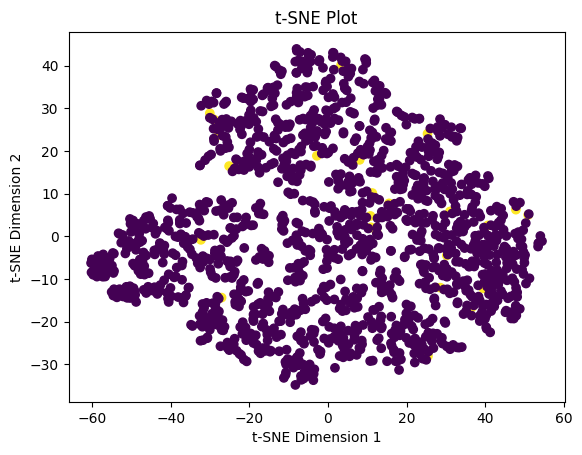

In [18]:
import matplotlib.pyplot as plt
# Plot t-SNE
plt.scatter(df_imp['coor_x'], df_imp['coor_y'], c= df_imp['Replication'])
plt.title('t-SNE Plot')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [19]:
l_cat = [col for col in df_categoric_replication.columns if col not in ['PATNR']]

# update column
df_imp['Replication'] = df_imp['Replication'].astype(float)

df_imp = df_imp.fillna(0)

l_cat_spec = l_cat.copy()
l_cat_spec.append('Replication')
l_cat_spec.append('PATNR')
l_cat_spec.append('PhenoGraph_clusters')
#l_cat_spec.pop(-5)


# Save embedding + projection
df_z.to_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Netherlands_embedding_projections.csv', index=False, sep=',')

# Important to start with RF -> (why i do not knwo)

func.visualize_umap_bokeh_na_2(X_embedded, df_imp[l_cat_spec],  l_cat_spec, l_binary=l_cat_spec, patient_id='PATNR', cluster_id='Replication', title='MMAE_UMAP2',  path='Netherlands/Netherlands_MMAE.html')

1414 1414
0 []

UMAP figure saved under location: TSNE/Baseline_MMAE_UMAP2.html


## #3 Classify novel instances (POODLE)

### #3.1 Initialize variables for patient assignment

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

df_cluster = metadata_RA[['pseudoId','PhenoGraph_clusters']].copy()

# Construct patient similarity matrix from original set
sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

# Specify columns for each modality (need to be present in both original & replication space)
d_input = {'cat' : list(df_categoric_replication[lcat].columns), 'num' : list(df_numeric_replication[lnum].columns)}

# Intialize list to save location of newly projected patients
z_new = []

# Define cluster
CLUSTER_LABEL = 'PhenoGraph_clusters'

# Initialize dataframe where we collect all predictors of interest for assigning patients to a cluster 
archetype_columns = ['weight_pval', 'weight_mean', 'weight_sd', 'cluster_mean_pat', 'cluster_sd_pat'] # + latent factors?
l_col = ['pseudoId', CLUSTER_LABEL]
for i in range(len(np.unique(df_cluster[CLUSTER_LABEL]))):
    l_col.extend(['%s_%s' % (col, i) for col in archetype_columns ])

df_characteristics = pd.DataFrame(columns=l_col)

### #3.2 Project the patients onto latent space and see how they are oriented

In [21]:
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import importlib as imp
import numpy 
imp.reload(pup)
np.seterr('raise') # reveal potential floating point errors

# Bookmark identifier (use fake)
df_id = pd.DataFrame({'pseudoId' : ['id_' + str(i) for i in range(len(df_numeric_replication))]})

for ix, new_pat in enumerate(df_id['pseudoId']):
    # collect sample information
    new_pat = str(df_id.iloc[ix]['pseudoId'])
    sample_cat = df_categoric_replication[lcat].iloc[ix]
    sample_num = df_numeric_replication[lnum].iloc[ix]
    #sample =  sample_cat.append(sample_num)
    sample = pd.concat([sample_cat, sample_num], axis=0)
    sample.name = new_pat

    # create metadata
    df_meta = pup.getMetaDataPatient(df_cluster, list(df_cluster['pseudoId'].values), new_pat)
    
    l_orientation = [df_id.iloc[ix]['pseudoId'], -1]
    
    # What is the orientation of the patient compared to each cluster
    # In other words, which cluster has the largest gravity on the patient
    l_orientation.extend(pup.getOrientation(autoencoder, df_meta, pd.DataFrame(z_filtered), d_input, sample, sim_matrix=sim_matrix, cluster_label='PhenoGraph_clusters'))

    # Bookmark cluster characteristics
    df_characteristics.loc[len(df_characteristics)] = l_orientation
    
df_characteristics['pseudoId'] = df_id['pseudoId'].copy()
df_characteristics.to_csv('Netherlands/ClusterCharacteristics_Projection_Netherlands.csv', index=False, sep=',')
df_characteristics.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,-1,1.000000,0.901704,0.08052,0.925388,0.060893,0.000001,0.948875,0.03964,...,0.000001,0.916618,0.064514,0.847620,0.070169,1.000000,0.834494,0.126516,0.883054,0.083619
1,id_1,-1,0.000001,0.901704,0.08052,0.846189,0.093394,0.000001,0.948875,0.03964,...,0.000001,0.916618,0.064514,0.778200,0.096459,0.995963,0.834494,0.126516,0.850430,0.097158
2,id_2,-1,1.000000,0.901704,0.08052,0.932886,0.049436,0.000002,0.948875,0.03964,...,0.004380,0.916618,0.064514,0.908204,0.057026,1.000000,0.834494,0.126516,0.870959,0.073004
3,id_3,-1,0.000020,0.901704,0.08052,0.886629,0.073773,0.000001,0.948875,0.03964,...,0.999976,0.916618,0.064514,0.928755,0.052611,1.000000,0.834494,0.126516,0.868160,0.095021
4,id_4,-1,1.000000,0.901704,0.08052,0.922122,0.051223,0.022753,0.948875,0.03964,...,0.858443,0.916618,0.064514,0.919921,0.054900,1.000000,0.834494,0.126516,0.862230,0.081899


### #3.3 Build Poodle classifier

#### #3.3.1 Quantify orientation of original samples with respect to clusters

In [ ]:
import pandas as pd
import numpy as np
from math import exp
from scipy.stats import ttest_ind
from scipy.spatial.distance import cosine# cosine minkowski
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
#import importlib as imp
#imp.reload(pup)
CLUSTER_LABEL = 'PhenoGraph_clusters'
# Initialize similarity matrix
# We only need to calculate the pairwise similarities of the initial space 1 time
sim_matrix = cosine_similarity(z_filtered.astype(np.float32))

df_characteristics_original = pup.quantifySimilarity(df_cluster, sim_matrix, CLUSTER_LABEL = 'PhenoGraph_clusters')
    
# Bookmark cluster characteristics
df_characteristics_original['pseudoId'] = df_cluster['pseudoId'].copy()
df_characteristics_original[CLUSTER_LABEL] = df_cluster[CLUSTER_LABEL].copy()
df_characteristics_original.to_csv('Netherlands/ClusterCharacteristics_Original.csv', index=False, sep=',')
df_characteristics_original.head()

#### #3.3.2 Optimize weights with simple classifier

TRAIN: [222 223 224 225 226 227 228 229 230 231] TEST: [0 1 2 3 4 5 6 7 8 9]
[13:07:36] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [222 223 224 225 226 227 228 229 230 231]
[13:07:37] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [444 445 446 447 448 449 450 451 452 453]
[13:07:37] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [666 667 668 669 670 671 672 673 674 675]
[13:07:37] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.

TRAIN: [0 1 2 3 4 5 6 7 8 9] TEST: [888 889 890 891 892 893 894 895 896 897]
[13:07:37] WARNING: ../src/learner.cc:767: 
Parameters: { "n_trees" } are not used.



Text(0.5, 1.0, 'Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: 1.00)')

<Figure size 640x480 with 0 Axes>

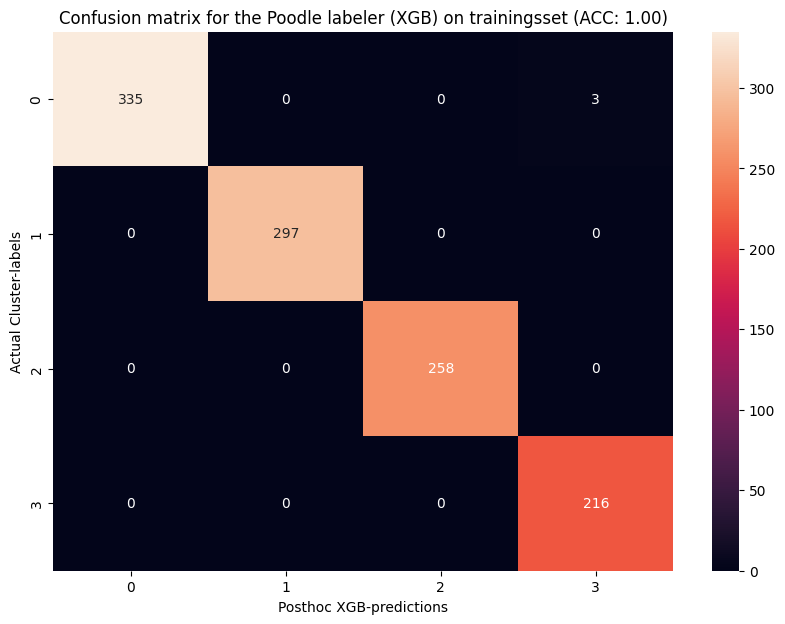

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt
import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

df_train, df_test = train_test_split(df_characteristics_original, test_size=0.2,  random_state=28072022) # stratify=df_characteristics['PhenoGraph_clusters'],

target = 'PhenoGraph_clusters'

cols_data = [x for x in list(df_train.columns) if x not in ['pseudoId', target]] #   'Sex', 'Age', 

X = df_train[cols_data].values
y = df_train[target]

# Apply 5 fold CV
kf = KFold(n_splits=5) # 
iteration = 0
y_pred = []
y_proba = []

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index[:10], "TEST:", test_index[:10])
    X_train, X_test = pd.DataFrame(X).loc[train_index], pd.DataFrame(X).loc[test_index]
    y_train, y_test = np.take(y, np.array(train_index)),np.take(y, np.array(test_index))#.values  # .values

    # Z-score scaling
    scaler = StandardScaler().fit(X_train)
    X_train= scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # Model is an XGBClassifier
    n_trees = 50
    dmat_train = xgb.DMatrix(X_train, y_train)
    dmat_test = xgb.DMatrix(X_test, y_test)
    
    t0 = time.time()
    xgb_clf = xgb.XGBClassifier(objective='multi:softmax', eval_metric='merror', num_class=len(y.unique()), n_trees=50)
    xgb_clf = xgb_clf.fit(X_train, y_train)

    
    t1 = time.time()
    #print('Time for Training XGB model %s: %s' % (str(iteration+1), str(t1-t0)))
    iteration += 1
    
    # Create a confusion matrix over all data!
    #y_pred.extend(bst.predict(dmat_test))
    y_proba.extend(xgb_clf.predict_proba(X_test))
    y_pred.extend(xgb_clf.predict(X_test))
    
fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)


df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) on trainingsset (ACC: %.2f)' % (accuracy))

#### #3.3.3 Show performance on hold-out test set

Text(0.5, 1.0, 'Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: 1.00)')

<Figure size 640x480 with 0 Axes>

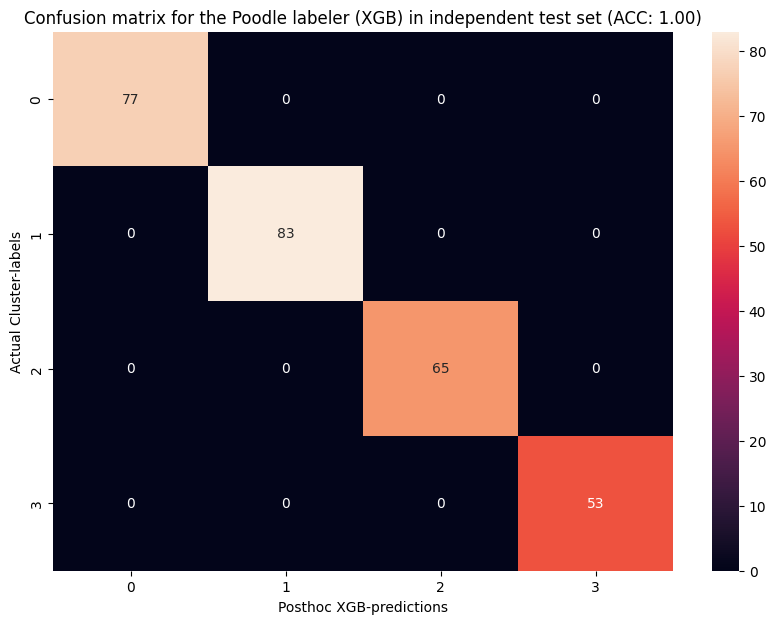

In [24]:
X_test_final = df_test[cols_data].values
y_test_final = df_test[target]

# Z-score scaling
#scaler = StandardScaler().fit(X_test)
X_test_final = scaler.transform(X_test_final)
y_pred_final = xgb_clf.predict(X_test_final)


fig = plt.figure()
cm = confusion_matrix(y_test_final, y_pred_final)
accuracy = accuracy_score(y_test_final, y_pred_final)


df_cm = pd.DataFrame(cm, index = list(range(len(y_test_final.unique()))),
                  columns = list(range(len(y_test_final.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Poodle labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.4 Compare to dummy classifier

Text(0.5, 1.0, 'Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: 0.59)')

<Figure size 640x480 with 0 Axes>

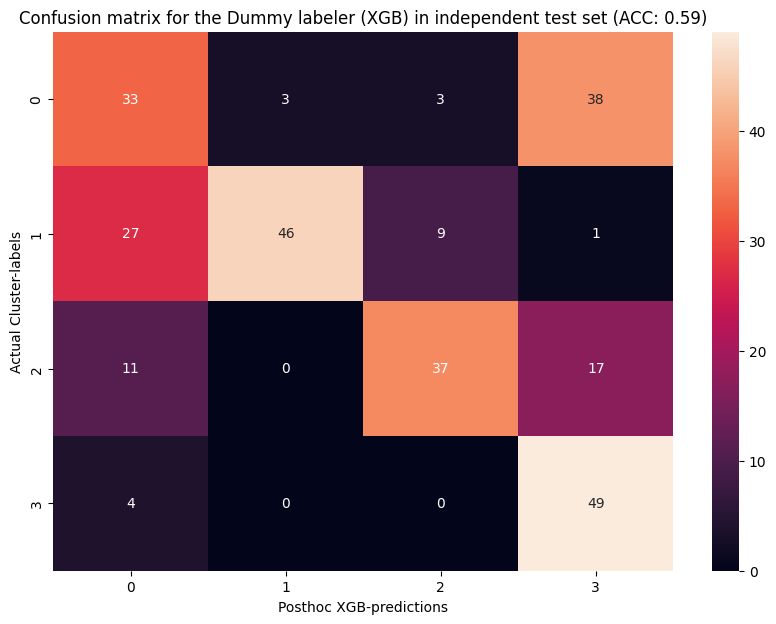

In [25]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score

def dummyLabeler(X):
    return np.argmax(X) # largest p

target = 'PhenoGraph_clusters'

X = df_test[[col for col in df_test.columns if 'weight_pval' in col]].copy()
y = df_test[target]

y_pred = []

for ix in range(len(X)): # loop through patients
    y_pred.append(dummyLabeler(X.iloc[ix]))

fig = plt.figure()
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

df_cm = pd.DataFrame(cm, index = list(range(len(y.unique()))),
                  columns = list(range(len(y.unique()))))
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.xlabel("Posthoc XGB-predictions")
plt.ylabel("Actual Cluster-labels")
plt.title('Confusion matrix for the Dummy labeler (XGB) in independent test set (ACC: %.2f)' % (accuracy))

#### #3.3.5 Train final model on all labeled data & Save model

In [26]:
from sklearn.model_selection import KFold
import xgboost as xgb
import matplotlib.pyplot as plt

import time
import seaborn as sn
from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from pickle import dump

X_all = df_characteristics_original[cols_data]
y_all = df_characteristics_original[CLUSTER_LABEL]

scaler = StandardScaler().fit(X_all)

X_all = scaler.transform(X_all)

dmat_train = xgb.DMatrix(X_all, y_all)

t0 = time.time()
bst  = xgb.train({'objective': 'multi:softmax',  'eval_metric':'merror', 'num_class':len(y.unique())}, dmat_train, # 'num_class':len(y.unique())
                    n_trees, evals=[(dmat_train, "train")]) # "tree_method": "gpu_hist", 'gamma': 8, , (dmat_test, "test")
t1 = time.time()

# save poodle labeler
bst.save_model("models/Netherlands_poodle/xgb_model.json")

# save scaler
dump(scaler, open('models/Netherlands_poodle/scaler.pkl', 'wb'))


[0]	train-merror:0.00000
[1]	train-merror:0.00000
[2]	train-merror:0.00000
[3]	train-merror:0.00000
[4]	train-merror:0.00000
[5]	train-merror:0.00000
[6]	train-merror:0.00000
[7]	train-merror:0.00000
[8]	train-merror:0.00000
[9]	train-merror:0.00000
[10]	train-merror:0.00000
[11]	train-merror:0.00000
[12]	train-merror:0.00000
[13]	train-merror:0.00000
[14]	train-merror:0.00000
[15]	train-merror:0.00000
[16]	train-merror:0.00000
[17]	train-merror:0.00000
[18]	train-merror:0.00000
[19]	train-merror:0.00000
[20]	train-merror:0.00000
[21]	train-merror:0.00000
[22]	train-merror:0.00000
[23]	train-merror:0.00000
[24]	train-merror:0.00000
[25]	train-merror:0.00000
[26]	train-merror:0.00000
[27]	train-merror:0.00000
[28]	train-merror:0.00000
[29]	train-merror:0.00000
[30]	train-merror:0.00000
[31]	train-merror:0.00000
[32]	train-merror:0.00000
[33]	train-merror:0.00000
[34]	train-merror:0.00000
[35]	train-merror:0.00000
[36]	train-merror:0.00000
[37]	train-merror:0.00000
[38]	train-merror:0.00

### #3.4 Use POODLE to cluster new instances

In [27]:
import sys
sys.path.append(r'../')
from poodle import utils as pup
import pandas as pd
from pickle import load

df_new = pd.read_csv('Netherlands/ClusterCharacteristics_Projection_Netherlands.csv', sep=',')

# Define input columns
target = 'PhenoGraph_clusters'
cols_data = [x for x in list(df_new.columns) if x not in ['pseudoId', target]]

# Classify patients
X_replication = df_new[cols_data]#.

# load the scaler
scaler = load(open('models/Netherlands_poodle/scaler.pkl', 'rb'))
#X_replication = scaler.transform(X_replication)

df_new['PhenoGraph_clusters'] = pup.classifyPatient(X_replication, path="models/Netherlands_poodle/")
df_new.to_csv('Netherlands/ClusterAssignment_Netherlands.csv', index=False, sep=',')
df_new.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,0.0,1.000000,0.901704,0.08052,0.925388,0.060893,0.000001,0.948875,0.03964,...,0.000001,0.916618,0.064514,0.847620,0.070169,1.000000,0.834494,0.126516,0.883054,0.083619
1,id_1,3.0,0.000001,0.901704,0.08052,0.846189,0.093394,0.000001,0.948875,0.03964,...,0.000001,0.916618,0.064514,0.778200,0.096459,0.995963,0.834494,0.126516,0.850430,0.097158
2,id_2,1.0,1.000000,0.901704,0.08052,0.932886,0.049436,0.000002,0.948875,0.03964,...,0.004380,0.916618,0.064514,0.908204,0.057026,1.000000,0.834494,0.126516,0.870959,0.073004
3,id_3,2.0,0.000020,0.901704,0.08052,0.886629,0.073773,0.000001,0.948875,0.03964,...,0.999976,0.916618,0.064514,0.928755,0.052611,1.000000,0.834494,0.126516,0.868160,0.095021
4,id_4,1.0,1.000000,0.901704,0.08052,0.922122,0.051223,0.022753,0.948875,0.03964,...,0.858443,0.916618,0.064514,0.919921,0.054900,1.000000,0.834494,0.126516,0.862230,0.081899


In [28]:
import pandas as pd
df_new = pd.read_csv('Netherlands/ClusterAssignment_Netherlands.csv', sep=',')

# Original clustering information (same samples as development set)
df_cluster = metadata_RA[['pseudoId', 'PhenoGraph_clusters']].copy()

Spatial variance in replication set: 	C1= 6; C2= 9; C3= 10; C4= 2
Spatial variance in original set: 	C1= 415; C2= 380; C3= 323; C4= 269


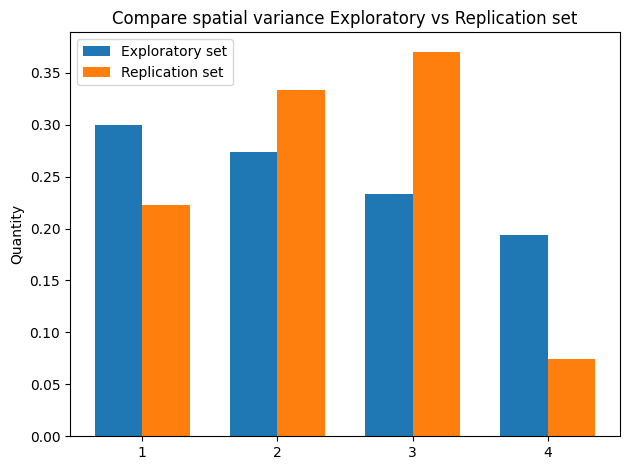

In [29]:
from collections import Counter
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import visualization as viz

c = Counter(df_new['PhenoGraph_clusters'])
l_new = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in replication set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))
c = Counter(df_cluster['PhenoGraph_clusters'])
l_old = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in original set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))

viz.plotSpatialVariation(l_new, l_old)

## Visualize joint involvement

In [30]:
import importlib as imp
import sys
sys.path.append(r'../../../src/1_emr_scripts')
import MannequinFunctions as func
imp.reload(func)

<module 'MannequinFunctions' from '../../../src/1_emr_scripts/MannequinFunctions.py'>

(-0.5, 1452.5, 1799.5, -0.5)

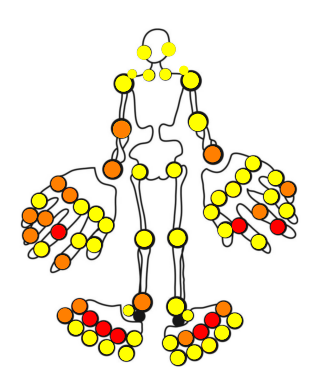

In [31]:
CLUSTER =3
CATEGORY = 'Zwelling' # 'Zwelling'
# Import mannequin information
df_man = pd.read_csv('Netherlands/Metadata_complete_Netherlands.csv', sep='|') 
df_man = df_man[df_man['Replication']==1].copy()
df_man['PhenoGraph_clusters'] = df_new['PhenoGraph_clusters'].copy()
df_cluster['PATNR']=df_cluster['pseudoId'].copy()
l_pat = set(df_man[df_man['PhenoGraph_clusters']==CLUSTER]['PATNR'])
df_sub = df_man[df_man['PATNR'].isin(l_pat)].copy()

#create scatterplot (toDo: for both big & small joints)
#l_col = [col for col in df_sub.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'PATNR']]
l_mannequin = [col for col in df_imp.columns if ((('Zwelling_' in col or 'Pijn_' in col)) and 'positive' in col)]
l_col = [col for col in l_mannequin ] #  if CATEGORY in col
df_plot = pd.DataFrame(df_sub[l_col].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
df_plot['s'] = df_plot['s'] #* df_plot['value']

# Visualize gestalt
im = plt.imread('../../../figures/2_processing/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='autumn_r')
fig = plt.gcf()
fig.set_dpi(100)
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
plt.axis('off')

### #3.6 Visualize Learned embedding

In [32]:
import sys
sys.path.append(r'../')
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup
import pandas as pd
import numpy as np

df_z = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/Netherlands_embedding_projections.csv', sep=',')
l_embedding = [col for col in df_z.columns]

# Variables from replication set
df_projection = pd.read_csv('Netherlands/ClusterAssignment_Netherlands.csv', sep=',')

# import metadata of SyG replication set
metadata_rep = pd.read_csv('Netherlands/Metadata_complete_Netherlands.csv', sep='|')
metadata_rep = metadata_rep[metadata_rep['Replication']==1].copy()
metadata_rep = metadata_rep.reset_index(drop=True)

# add cluster info for projected patietns
metadata_rep['PhenoGraph_clusters'] = df_projection['PhenoGraph_clusters'].copy() # len(metadata['PhenoGraph_clusters'].unique())+1

# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0

# Combine both metadatas
metadata = metadata_RA.append(metadata_rep, ignore_index = True)

# Add projected patients to original set
l_latent = [col for col in l_embedding if col not in ['pseudoId', 'PATNR']]

print('BEFORE: total samples for tsne: ', len(metadata_RA))
metadata_total, z_total = pup.add_projected_patients(metadata_RA, pd.DataFrame(z_filtered, columns=l_latent), metadata_rep, z_patient[l_latent]) # ix = 
print('After: total samples for tsne: ', len(metadata_total))

BEFORE: total samples for tsne:  1387
After: total samples for tsne:  1414


/tmp/ipykernel_136844/3813390114.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metadata = metadata_RA.append(metadata_rep, ignore_index = True)


In [33]:
metadata_total.to_csv('Netherlands/Netherlands_Complete_META.csv', sep=';', index=None)

In [34]:
from umap.parametric_umap import ParametricUMAP
import importlib as imp

SEED = 20230409

embedder = ParametricUMAP(random_state=SEED)
embedding = embedder.fit_transform(z_filtered)
pup.plot_tsne(embedding, group_id=metadata_RA['PhenoGraph_clusters'], path='Netherlands/umap_original_Netherlands.png')

# save parametric UMAP
embedder.save('../../models/umap/umap_mapping_Netherlands')

/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/umap/parametric_umap.py:269: UserWarning: Data should be scaled to the range 0-1 for cross-entropy reconstruction loss.
  warn(


Epoch 1/10
17/17 [==============================] - 1s 38ms/step - loss: 0.3517
Epoch 2/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2978
Epoch 3/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2837
Epoch 4/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2784
Epoch 5/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2738
Epoch 6/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2746
Epoch 7/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2707
Epoch 8/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2702
Epoch 9/10
17/17 [==============================] - 1s 38ms/step - loss: 0.2659
Epoch 10/10
17/17 [==============================] - 1s 41ms/step - loss: 0.2703
INFO:tensorflow:Assets written to: ../../models/umap/umap_mapping_Netherlands/encoder/assets
Keras encoder model saved to ../../models/umap/umap_mapping_Netherlands/encoder
INFO:tensorflow:Assets wri

In [35]:
# Project replication data onto tSNE
fit2 = embedder.transform(z_total.values)

# Plot Umap as 2d image
pup.plot_tsne(fit2, group_id=metadata_total['Replication'], path='Netherlands/umap_replication_projected_Netherlands.png')


### Create Cluster table 
use metadata_total

In [36]:
import pandas as pd
metadata_total = pd.read_csv('Netherlands/Netherlands_Complete_META.csv', sep=';')
extra_meta = pd.read_csv('Leiden_20240401.csv', sep=';')

df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
# Drop columns with only missing values
df_subset = df_subset.dropna(axis=1, how='all')
df_full = pd.merge(df_subset, extra_meta, left_on='PATNR', right_on='SubjectId')
df_full = df_full.drop_duplicates(subset='SubjectId', keep='first')

In [37]:
import numpy as np

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]

df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'ESR (median+-IQR)', 'DAS28 (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'ESR_na [n(%)]' , 'Mannequin_na [n(%)]']) #TreatSwitch [n(%)]', 

#df_subset = metadata_total[metadata_total['Replication']==1].reset_index(drop=True)# 'DAS28 (median+-IQR)',
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['BSE'].isna()]['BSE']), IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[0], IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration']), IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[0], IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['BSE'].isna()]), (len(df_baseline[df_baseline['BSE'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100)
     
    ]
#df_summary.loc[0] = generate_baseline_ref(df_full, 'All')

for i in range(len(df_full['PhenoGraph_clusters'].unique())):
    df_summary.loc[i] = generate_baseline_ref(df_full[df_full['PhenoGraph_clusters']==i], 'Cluster %s' % str(i+1))

df_summary = df_summary.reset_index(drop=True)
df_summary.T

,0,1,2,3
cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4
N,6,9,10,2
"Sex, F [n(%)]",6 (100.0),4 (44.4),6 (60.0),1 (50.0)
Age (median+-IQR),48.0 (46.5-50.0),53.0 (48.0-65.0),47.5 (35.5-55.0),57.5 (57.5-57.5)
RF [n(%)],4.0 (66.7),9.0 (100.0),10.0 (100.0),2.0 (100.0)
ACPA [n(%)],4.0 (66.7),8.0 (88.9),9.0 (90.0),2.0 (100.0)
ESR (median+-IQR),17.0 (12.5-31.0),29.0 (14.0-39.0),28.5 (10.5-32.0),57.0 (57.0-57.0)
DAS28 (median+-IQR),4.5 (4.0-4.7),5.2 (4.4-5.5),4.1 (3.7-4.6),4.0 (4.0-4.0)
SJC (median+-IQR),6.0 (5.0-7.5),14.0 (10.0-18.0),6.0 (4.5-8.0),9.0 (9.0-9.0)
TJC (median+-IQR),7.0 (5.5-9.5),14.0 (12.0-17.0),11.0 (8.0-13.0),11.5 (11.5-11.5)
